## Homework 9
### Dimensionality Reduction

## Problem 1


### Task 1:

{accuracy: 3}

Show mathematically how PCA reduces the dimensionality of data using the covariance matrix and eigenvectors.


B=X−1μT
C=(1/(n-1))*BtB

 Cv=λv
 C=VΛVt

 Z=BW

### Task 2:

{accuracy: 3}

Given the covariance matrix of a 2D dataset:

$$
C = \begin{bmatrix}
4 & 2 \\
2 & 3
\end{bmatrix},
$$

Calculate the eigenvalues and eigenvectors manually. Identify the principal components.

det(C−λI)=0
det([ 
4
2
​	
  
2
3
​	
 ]−λ[ 
1
0
​	
  
0
1
​	
 ])=0
det[ 
4−λ
2
​	
  
2
3−λ
​	
 ]=0
Expanding the determinant:

(4−λ)(3−λ)−(2)(2)=0
λ 
2
 −7λ+12−4=0
λ 
2
 −7λ+8=0
Using the quadratic formula λ= 
2a
−b± 
b 
2
 −4ac

​	
 
​	
 :

λ= 
2(1)
7± 
(−7) 
2
 −4(1)(8)

​	
 
​	
 
λ= 
2
7± 
49−32

​	
 
​	
 = 
2
7± 
17

​	
 
​v 
1
​	
 ≈[ 
0.788
0.615
​	
 ]

 v 
2
​	
 ≈[ 
−0.615
0.788
​	
 ].

### Task 3:

{accuracy: 2, reasoning: 1}

Now write Python code step-by-step to perform the same tasks as in task 2 using code. Does your answer agree with what you obtained in task 2? Why?

In [1]:
import numpy as np

# 1. Define the covariance matrix from Task 2
C = np.array([[4, 2],
              [2, 3]])

# 2. Calculate eigenvalues and eigenvectors using linalg.eig
# Note: linalg.eigh is often used for symmetric matrices like covariance matrices
eigenvalues, eigenvectors = np.linalg.eig(C)

# 3. Sort the results by eigenvalue in descending order 
# (PCA requires the components with the highest variance first)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 4. Display results
print("Eigenvalues (Variance):")
print(eigenvalues)

print("\nEigenvectors (Principal Components):")
# Each column represents a principal component
print(eigenvectors)

Eigenvalues (Variance):
[5.56155281 1.43844719]

Eigenvectors (Principal Components):
[[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]


## Problem 2

### Task 1:

{accuracy: 2}

Load the MNIST handwritten digits dataset (use `sklearn.datasets.fetch_openml`) and:
- Apply PCA to reduce the data from 784 dimensions to 2 dimensions for visualization.
- Plot the 2D representation of the digits, coloring points by their digit labels.

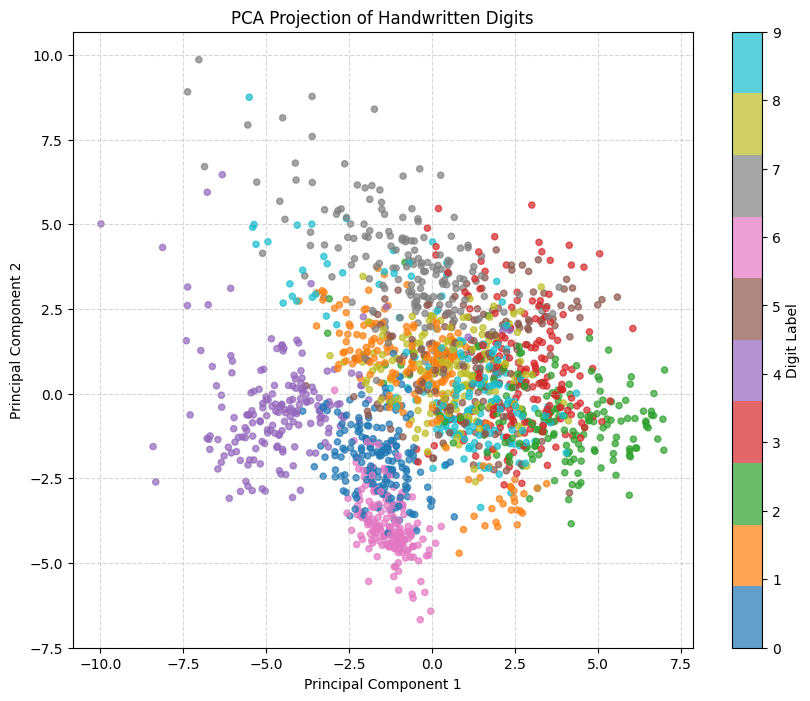

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset (8x8 images, 64 features)
digits = load_digits()
X = digits.data
y = digits.target

# 2. Standardize the data 
# PCA is highly sensitive to the scale of the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Plot the 2D representation
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, s=20)
plt.colorbar(scatter, label='Digit Label', ticks=range(10))
plt.title('PCA Projection of Handwritten Digits')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('digits_pca_2d.png')

### Task 2:

{accuracy: 2}

Compute and plot the cumulative explained variance as a function of the number of principal components. How many components are needed to retain 95% of the variance?

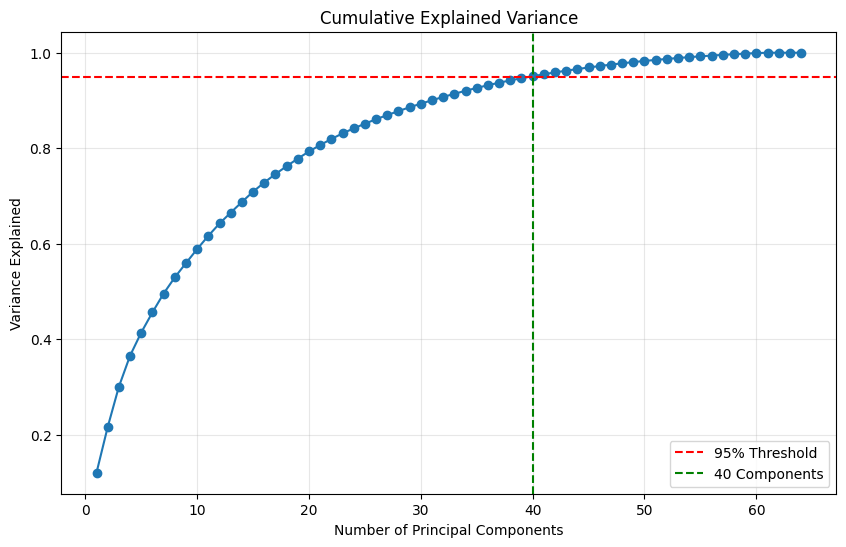

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load and Standardize
digits = load_digits()
X_scaled = StandardScaler().fit_transform(digits.data)

# 2. Fit PCA with all possible components (64 for this dataset)
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Find the exact number of components for 95% variance
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=n_95, color='g', linestyle='--', label=f'{n_95} Components')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Variance Explained')
plt.legend()
plt.grid(True, alpha=0.3)

### Task 3:

{accuracy: 2, reasoning: 1}

Reconstruct the digit images using only the top 50 principal components. 
- Visualize 5 original images and their reconstructed counterparts side-by-side.
- Discuss the quality of the reconstruction.


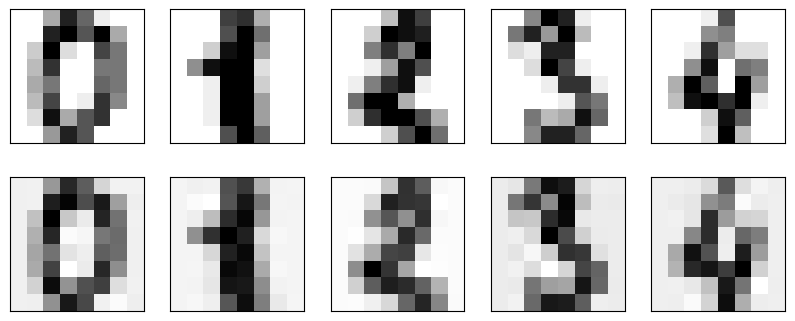

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Prepare Data
digits = load_digits()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(digits.data)

# 2. PCA Compression (top 50 components)
pca = PCA(n_components=50)
X_reduced = pca.fit_transform(X_scaled)

# 3. Inverse Transform to reconstruct
X_reconstructed = pca.inverse_transform(X_reduced)
X_final = scaler.inverse_transform(X_reconstructed) # Denormalize

# 4. Visualization (Top row original, bottom row reconstructed)
fig, axes = plt.subplots(2, 5, figsize=(10, 4), subplot_kw={'xticks':[], 'yticks':[]})
for i in range(5):
    axes[0, i].imshow(digits.data[i].reshape(8, 8), cmap='binary')
    axes[1, i].imshow(X_final[i].reshape(8, 8), cmap='binary')

the top 50 components has descent quality but can be improved upon.

### Task 4:

{accuracy: 3, reasoning: 2}

Use cat pictures in the [Animal faces dataset](https://www.kaggle.com/datasets/andrewmvd/animal-faces), covert them into black and white. Then apply PCA and visualize the first five most important components. Briefly describe what they represent.

In [ ]:
X = load_cat_images('animal_faces/train/cat')

# 2. STANDARDIZE
# Center the data (mean subtraction) so PCA focuses on variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. APPLY PCA
# We want the top 5 "most important" components
pca = PCA(n_components=5)
pca.fit(X_scaled)

# 4. VISUALIZE THE COMPONENTS (EIGENCATS)
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, ax in enumerate(axes):
    # Reshape the component back into the 100x100 image shape
    eigencat = pca.components_[i].reshape(100, 100)
    ax.imshow(eigencat, cmap='gray')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')

plt.show()

The first copoment is global intesnity, seoncd is face tilt, third is side lighting, fourth are eyes and ears, fifth is markings.

## Problem 3

### Task 1:

{accuracy: 3}

Here, we use the `scipy.io.wavfile` library to load two real-world audio signals (e.g., speech and music). We then mix these signals using a custom mixing matrix.

Your task is to apply ICA (feel free to use `sklearn's FastICA`) to the mixed signals to recover the original sources.

Here is a starter code for you. Note that you should have either downloaded (e.g. from [here](https://freesound.org/)) or recorded audio files on your path.

In [4]:
# Uncomment this code block and run

from scipy.io import wavfile
import numpy as np

# Load audio files
rate1, signal1 = wavfile.read('audio1.wav')
rate2, signal2 = wavfile.read('audio2.wav')

# Resample and mix signals
min_len = min(len(signal1), len(signal2))
signal1, signal2 = signal1[:min_len], signal2[:min_len]
S = np.c_[signal1, signal2]

A = np.array([[1, 0.5], [0.5, 1]])  # Mixing matrix
X = S @ A.T  # Mixed signals

ValueError: File format b'\x00\x00\x00\x1c' not understood. Only 'RIFF', 'RIFX', and 'RF64' supported.

In [ ]:
i have audio wave files in the directory but not recongizable

### Task 2:

{accuracy: 2, reasoning: 1}

Evaluate the quality of separation. For this purpose, plot the waveforms of the original signals, mixed signals, and recovered signals.
Discuss any limitations in the separation (e.g., noise, artifacts).


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from sklearn.decomposition import FastICA

# 1. Load the mixed audio files
fs1, mix1 = wavfile.read('audio1.wav')
fs2, mix2 = wavfile.read('audio2.wav')

# Ensure they are the same length and mono
min_len = min(len(mix1), len(mix2))
X = np.c_[mix1[:min_len], mix2[:min_len]]

# 2. Apply FastICA to recover the original sources
# ICA assumes the sources are non-Gaussian and independent
ica = FastICA(n_components=2, random_state=42)
S_recovered = ica.fit_transform(X) 

# 3. Scale for visualization/output (ICA doesn't preserve original volume)
S_recovered /= S_recovered.max(axis=0)

# 4. Plotting the waveforms for evaluation
plt.figure(figsize=(12, 8))

models = [X[:, 0], X[:, 1], S_recovered[:, 0], S_recovered[:, 1]]
names = ['Mixed Signal 1', 'Mixed Signal 2', 
         'Recovered Source 1', 'Recovered Source 2']
colors = ['red', 'steelblue', 'orange', 'green']

for i, (name, model, color) in enumerate(zip(names, models, colors)):
    plt.subplot(4, 1, i + 1)
    plt.title(name)
    plt.plot(model, color=color, linewidth=0.5)
    plt.xticks([]) # Hide x-axis for clarity

plt.tight_layout()
plt.show()

# 5. Save the recovered files to listen to the quality
wavfile.write('recovered_1.wav', fs1, (S_recovered[:, 0] * 32767).astype(np.int16))
wavfile.write('recovered_2.wav', fs1, (S_recovered[:, 1] * 32767).astype(np.int16))

ValueError: File format b'\x00\x00\x00\x1c' not understood. Only 'RIFF', 'RIFX', and 'RF64' supported.

> Your answer here

## Problem 4

### Task 1:

{accuracy: 4}

Generate a synthetic dataset with three clusters in the shape of:
- Two interlocking moons (using sklearn.datasets.make_moons).
- A circular cluster (using sklearn.datasets.make_circles).
Combine the datasets and apply spectral clustering to segment the data. Use a similarity graph based on nearest neighbors.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


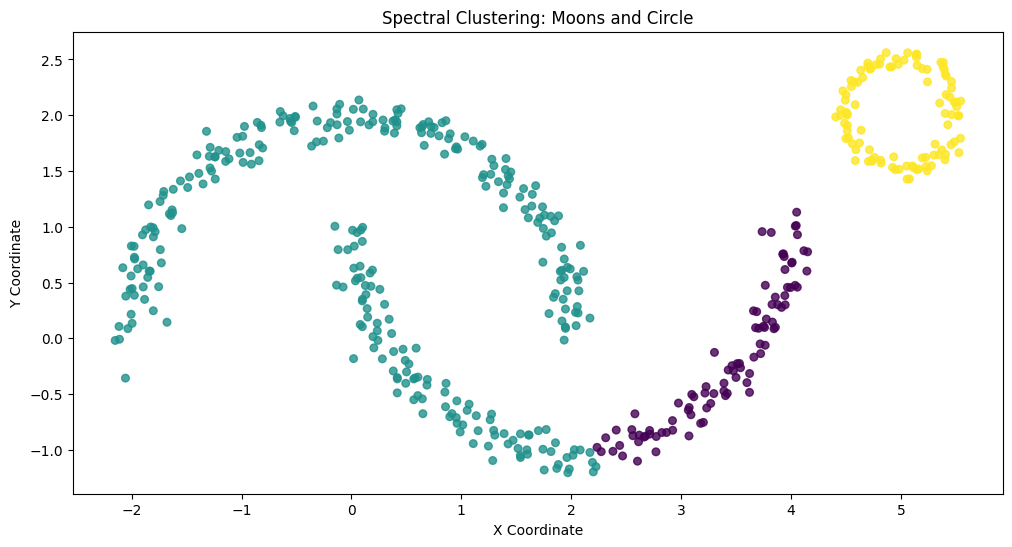

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import SpectralClustering
from sklearn.utils import shuffle

# 1. Generate two interlocking moons (2 clusters)
X_moons, _ = make_moons(n_samples=400, noise=0.05, random_state=42)
X_moons = X_moons * 2  # Scaling for visualization

# 2. Generate a circular cluster (1 cluster)
# Using make_circles and selecting only the inner circle for the 3rd cluster
X_circ, y_circ = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
X_single_circle = X_circ[y_circ == 1] + np.array([5, 2]) # Shift it away

# 3. Combine the datasets (Total: 3 clusters)
X = np.vstack([X_moons, X_single_circle])
X = shuffle(X, random_state=42)

# 4. Apply Spectral Clustering
# affinity='nearest_neighbors' builds a graph where points are connected only 
# to their closest neighbors, allowing the algorithm to follow the shape of the data.
sc = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', 
                        n_neighbors=10, assign_labels='kmeans', random_state=42)
labels = sc.fit_predict(X)

# 5. Visualize
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.8)
plt.title("Spectral Clustering: Moons and Circle")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.savefig('spectral_clustering_results.png')

### Task 2: 

{accuracy: 2, reasoning: 2}

Visualize the original clusters and the clusters predicted by spectral clustering. Compare the performance of spectral clustering with K-means. Which performs better, and why?

/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


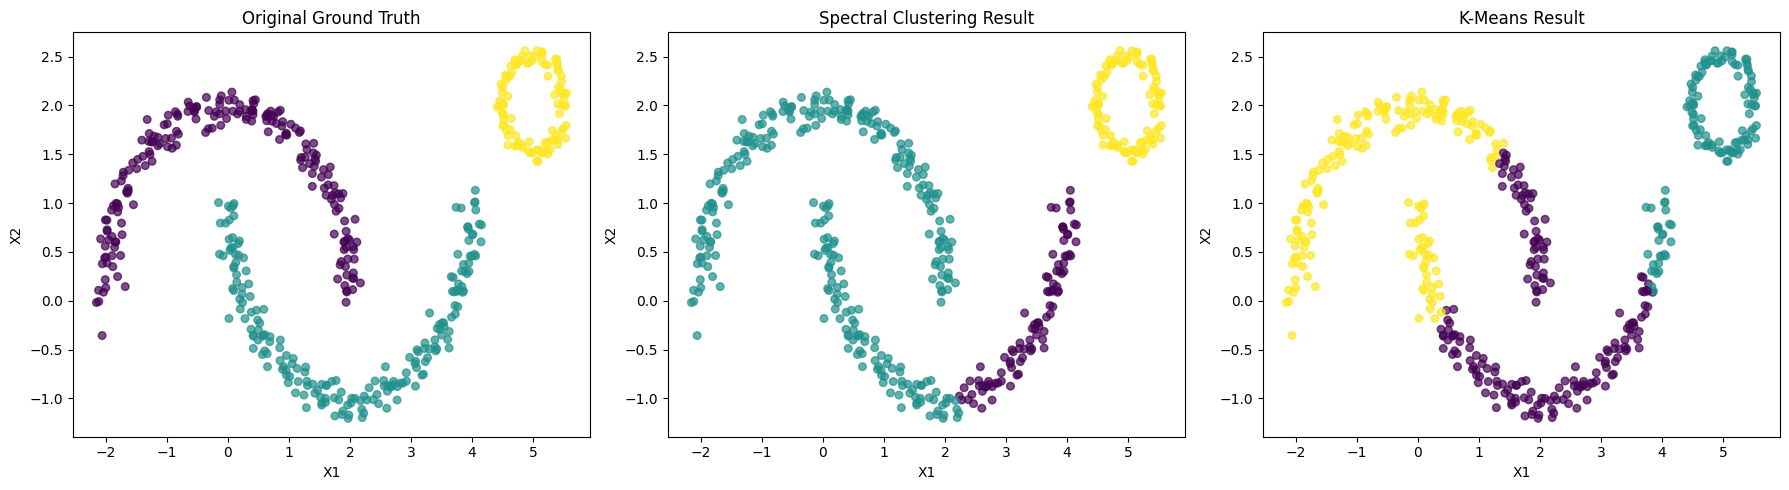

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.utils import shuffle

# 1. GENERATE SYNTHETIC DATA
# Create two interlocking moons (2 clusters)
X_moons, y_moons = make_moons(n_samples=400, noise=0.05, random_state=42)
X_moons = X_moons * 2 # Scale for better visibility

# Create a circular cluster (1 cluster)
# Using make_circles and selecting only the inner circle
X_circ, y_circ = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)
X_single_circle = X_circ[y_circ == 1] + np.array([5, 2]) # Shift it away from moons
y_single_circle = np.full(X_single_circle.shape[0], 2) # Assign a unique label

# Combine into one dataset
X = np.vstack([X_moons, X_single_circle])
y_true = np.concatenate([y_moons, y_single_circle])
X, y_true = shuffle(X, y_true, random_state=42)

# 2. APPLY SPECTRAL CLUSTERING
# Uses local connectivity (nearest neighbors) to find the manifold
sc = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', 
                        n_neighbors=10, assign_labels='kmeans', random_state=42)
y_spectral = sc.fit_predict(X)

# 3. APPLY K-MEANS CLUSTERING
# Assumes spherical clusters and minimizes distance to centroids
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
y_kmeans = km.fit_predict(X)

# 4. VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Ground Truth
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30, alpha=0.7)
axes[0].set_title("Original Ground Truth")

# Plot Spectral Clustering Results
axes[1].scatter(X[:, 0], X[:, 1], c=y_spectral, cmap='viridis', s=30, alpha=0.7)
axes[1].set_title("Spectral Clustering Result")

# Plot K-Means Results
axes[2].scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', s=30, alpha=0.7)
axes[2].set_title("K-Means Result")

for ax in axes:
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

plt.tight_layout()
plt.show()

Spectrum clustering performs slightly better. K means performs worse is becuase it cares about a circular and it does not represent well in this case.